In [1]:
import sys

print("Python Executable")
print(sys.executable)

Python Executable
c:\Users\HP\Desktop\RF Signal Processing\RF-Signal-Classification-using-ML\venv\Scripts\python.exe


In [2]:
import pickle
import numpy as np
from pathlib import Path

In [3]:
PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)

c:\Users\HP\Desktop\RF Signal Processing\RF-Signal-Classification-using-ML


In [4]:
DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "RML2016.10a_dict.pkl"

print(DATASET_PATH)
print(DATASET_PATH.exists())

c:\Users\HP\Desktop\RF Signal Processing\RF-Signal-Classification-using-ML\data\raw\RML2016.10a_dict.pkl
True


In [5]:
with open(DATASET_PATH, "rb") as file:
    dataset = pickle.load(file, encoding="latin1")

print("✅ Dataset Loaded Successfully!")

✅ Dataset Loaded Successfully!


In [6]:
print(type(dataset))
print("Number of Keys:", len(dataset))

<class 'dict'>
Number of Keys: 220


In [7]:
modulations = sorted(list(set(k[0] for k in dataset.keys())))
snrs = sorted(list(set(k[1] for k in dataset.keys())))

print("Modulation Types:")
print(modulations)

print()

print("SNR Levels:")
print(snrs)

Modulation Types:
['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']

SNR Levels:
[-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [8]:
print("Number of Modulation Types:", len(modulations))
print("Number of SNR Levels:", len(snrs))

Number of Modulation Types: 11
Number of SNR Levels: 20


In [9]:
first_key = list(dataset.keys())[0]

print(first_key)

('QPSK', 2)


In [10]:
sample = dataset[first_key]

print(type(sample))
print(sample.shape)

<class 'numpy.ndarray'>
(1000, 2, 128)


In [11]:
from pathlib import Path

FIGURE_PATH = PROJECT_ROOT / "results" / "figures"

FIGURE_PATH.mkdir(parents=True, exist_ok=True)

print(FIGURE_PATH)

c:\Users\HP\Desktop\RF Signal Processing\RF-Signal-Classification-using-ML\results\figures


In [12]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


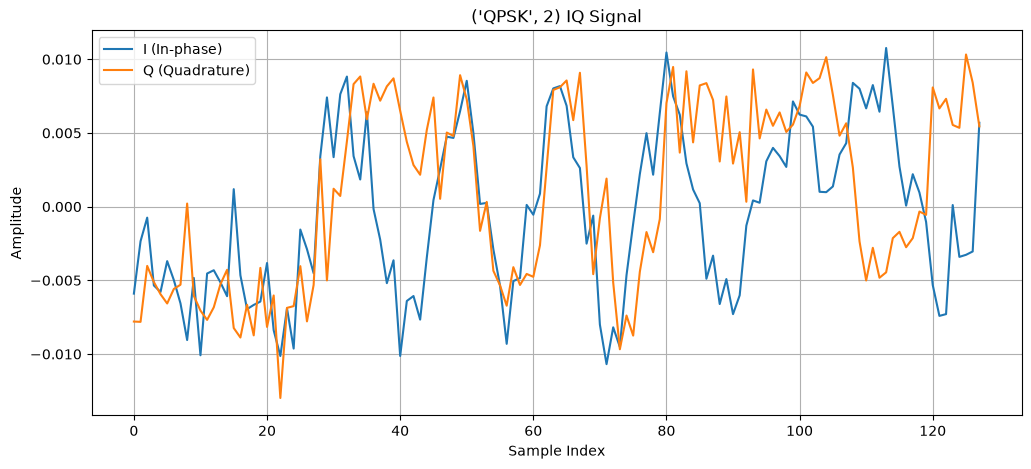

In [13]:
import matplotlib.pyplot as plt

# Select the first RF signal
iq_signal = sample[0]

I = iq_signal[0]
Q = iq_signal[1]

plt.figure(figsize=(12,5))

plt.plot(I, label="I (In-phase)")
plt.plot(Q, label="Q (Quadrature)")

plt.title(f"{first_key} IQ Signal")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
sample.shape

(1000, 2, 128)

In [15]:
iq_signal = sample[0]

print(iq_signal.shape)

(2, 128)


In [16]:
I = iq_signal[0]
Q = iq_signal[1]

print("I Shape:", I.shape)
print("Q Shape:", Q.shape)

I Shape: (128,)
Q Shape: (128,)


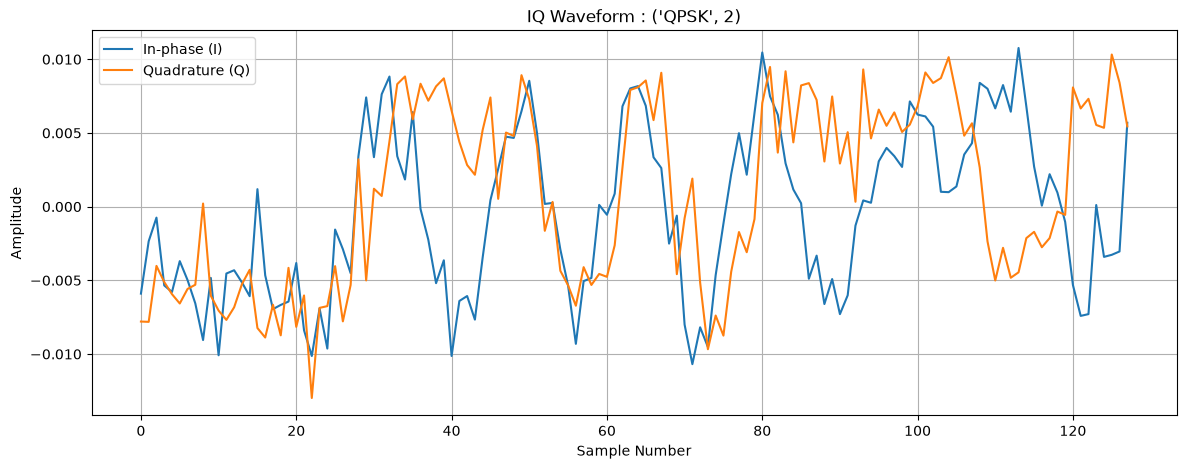

In [17]:
plt.figure(figsize=(14,5))

plt.plot(I, label="In-phase (I)")
plt.plot(Q, label="Quadrature (Q)")

plt.title(f"IQ Waveform : {first_key}")

plt.xlabel("Sample Number")

plt.ylabel("Amplitude")

plt.grid(True)

plt.legend()

plt.show()

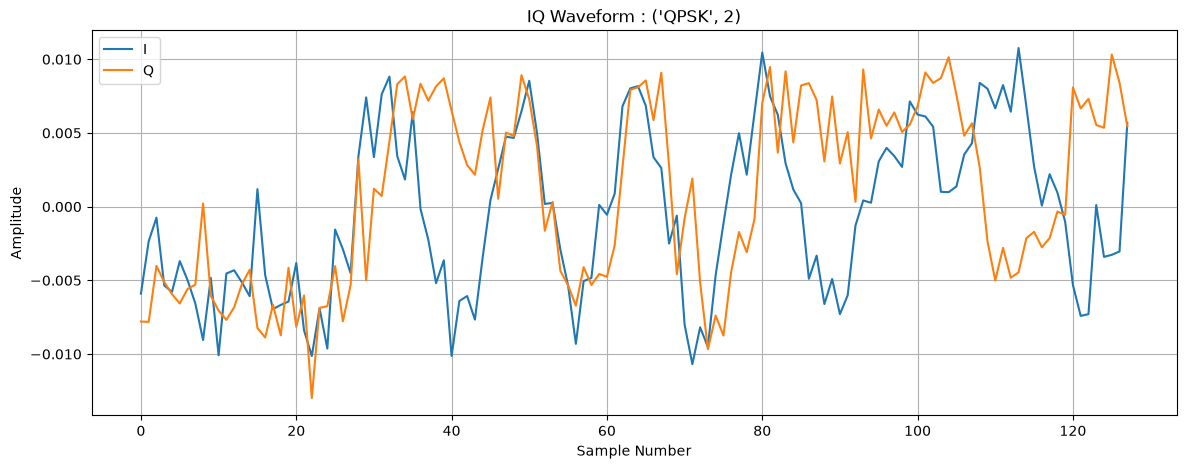

In [18]:
plt.figure(figsize=(14,5))

plt.plot(I,label="I")

plt.plot(Q,label="Q")

plt.title(f"IQ Waveform : {first_key}")

plt.xlabel("Sample Number")

plt.ylabel("Amplitude")

plt.legend()

plt.grid(True)

plt.savefig(FIGURE_PATH/"IQ_Waveform.png",dpi=300)

plt.show()

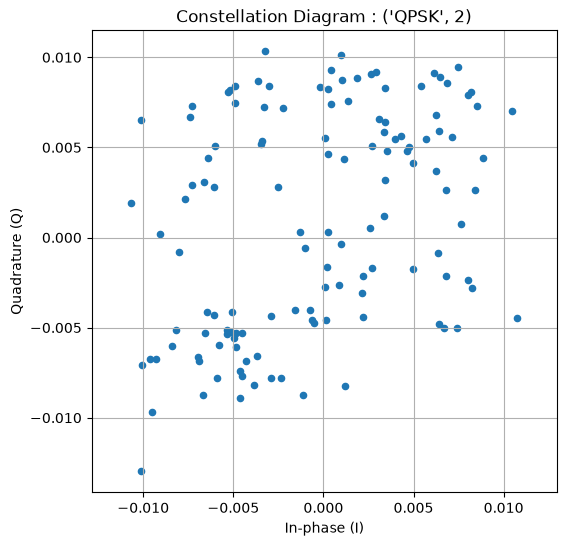

In [19]:
plt.figure(figsize=(6,6))

plt.scatter(I,Q,s=20)

plt.title(f"Constellation Diagram : {first_key}")

plt.xlabel("In-phase (I)")

plt.ylabel("Quadrature (Q)")

plt.grid(True)

plt.axis("equal")

plt.savefig(FIGURE_PATH/"Constellation.png",dpi=300)

plt.show()

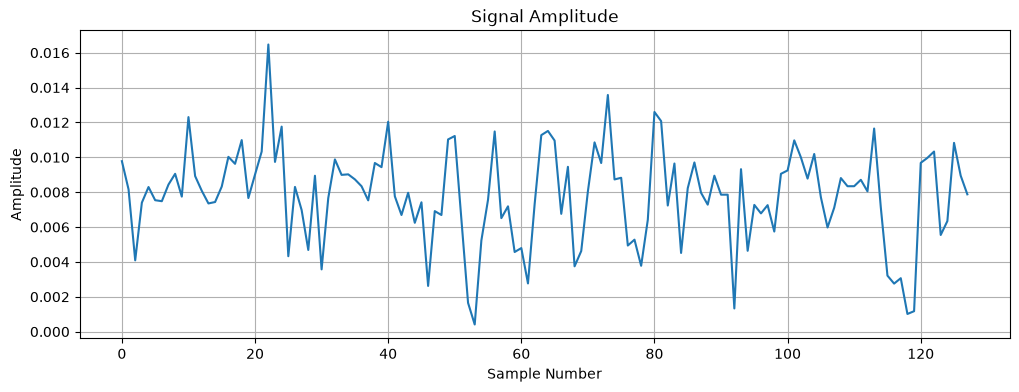

In [20]:
amplitude = np.sqrt(I**2 + Q**2)

plt.figure(figsize=(12,4))

plt.plot(amplitude)

plt.title("Signal Amplitude")

plt.xlabel("Sample Number")

plt.ylabel("Amplitude")

plt.grid(True)

plt.savefig(FIGURE_PATH/"Amplitude.png",dpi=300)

plt.show()

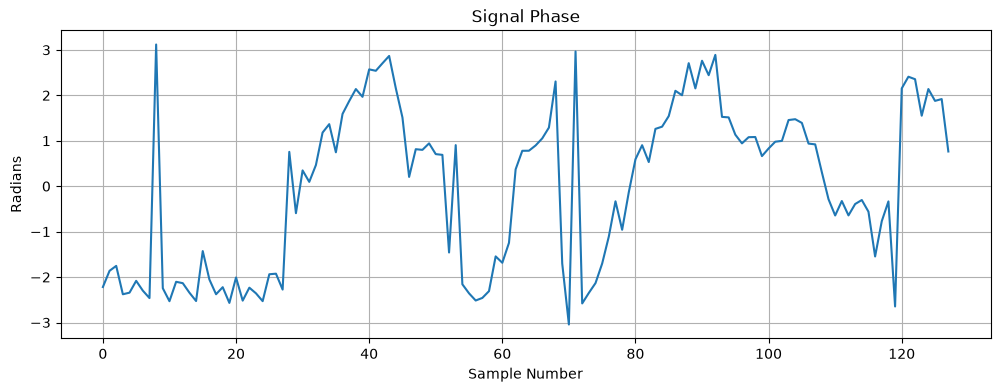

In [21]:
phase = np.arctan2(Q,I)

plt.figure(figsize=(12,4))

plt.plot(phase)

plt.title("Signal Phase")

plt.xlabel("Sample Number")

plt.ylabel("Radians")

plt.grid(True)

plt.savefig(FIGURE_PATH/"Phase.png",dpi=300)

plt.show()